# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [11]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

In [12]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [13]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [15]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [16]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [17]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [18]:
print(data[['sex', 'sex_label']].drop_duplicates())
print()
print(data.filter(like='embarked').drop_duplicates())

      sex  sex_label
0    male          1
1  female          0

   embarked  embarked_C  embarked_Q  embarked_S
0         S       False       False        True
1         C        True       False       False
5         Q       False        True       False
61      NaN       False       False       False


##### LabelEncoder asigna un número entero a cada categoría (ej. female=0, male=1), lo cual crea una relación de orden artificial entre categorías que no necesariamente existe. Es adecuado para variables binarias o con orden real (ordinales). OneHotEncoder (o pd.get_dummies) crea una columna binaria por cada categoría, evitando implicar un orden falso. Es más adecuado para variables categóricas nominales (sin orden), aunque incrementa el número de columnas.

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

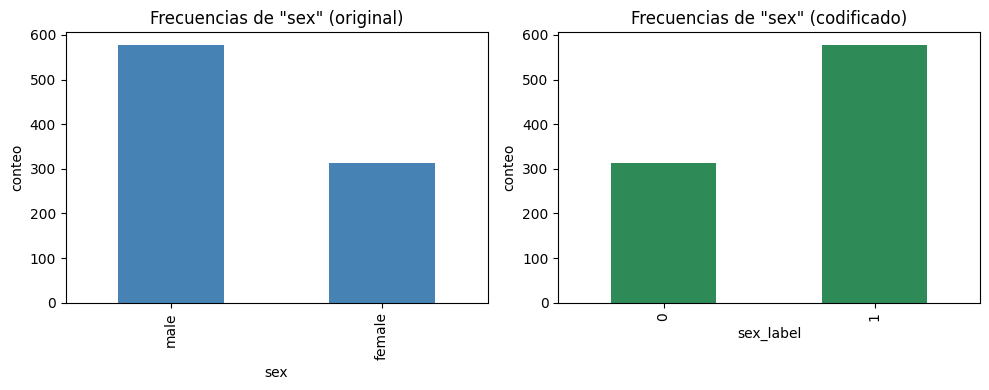

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

data['sex'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Frecuencias de "sex" (original)')
axes[0].set_xlabel('sex')
axes[0].set_ylabel('conteo')

data['sex_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Frecuencias de "sex" (codificado)')
axes[1].set_xlabel('sex_label')
axes[1].set_ylabel('conteo')

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [21]:
class_onehot = pd.get_dummies(data['class'], prefix='class')
data = pd.concat([data, class_onehot], axis=1)
print(data.filter(like='class').head())

   pclass  class  class_First  class_Second  class_Third
0       3  Third        False         False         True
1       1  First         True         False        False
2       3  Third        False         False         True
3       1  First         True         False        False
4       3  Third        False         False         True


##### Ventajas frente a LabelEncoder son: No introduce un orden artificial entre 'First', 'Second' y 'Third' (LabelEncoder los convertiría en 0,1,2 dando a entender una relación numérica inexistente). Esto evita que modelos lineales o basados en distancia interpreten mal la relación entre clases.

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

##### Para variables categóricas nominales (sin orden), como 'sex', 'embarked' o 'class', usaría OneHotEncoder, ya que evita imponer relaciones de orden falsas que podrían confundir a modelos sensibles a la magnitud de los valores (regresión lineal/logística, SVM, KNN, redes neuronales). Reservaría LabelEncoder para variables binarias (donde 0/1 no genera ambigüedad) o variables verdaderamente ordinales (ej. nivel educativo), y para modelos basados en árboles (Random Forest, XGBoost), que manejan bien codificaciones enteras sin verse afectados por el orden implícito.